In [1]:
%load_ext autoreload
%autoreload 2

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

from utils import quality_metrics
# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)

In [34]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [35]:
df = pd.read_excel(os.path.join("../data/predicted_flood_depths_2025-05-13.xlsx"))
df = df[
    df["measured_depth"]<4
]
df.shape
# Replace 0 values with 0.01 for all measured_depth
# df["measured_depth"] = df["measured_depth"].replace(0, 0.01)

(11740, 25)

In [ ]:
plt.show()


In [37]:
# Show number of samples, split by event
event_sample_counts = df["DogodekId"].value_counts()
print("Number of samples split by event:")
print(event_sample_counts)

# SUM
df.shape

Number of samples split by event:
DogodekId
68    6568
14    2477
18    1797
24     898
Name: count, dtype: int64


(11740, 25)

In [25]:
df.head(2)

,VlogaId,Objekt_Naslov,Objekt_Naslov_PostnaStevilka,Objekt_Parcela_Stevilka,Objekt_Parcela_KoId,Objekt_UporabnaPovrsina,Objekt_VisinaVodeCm,Objekt_StopnjaPoskodovanosti,Skoda_DatumOcene,Objekt_VrstaObjektaId,DogodekId,Vrednost,OdstPoskodovanostiObjekta,SkupnaSkoda,SkupnaSkodaSource,geometry,gps_lat,gps_lng,predicted_wri_depth,predicted_si_depth,predicted_si_old_depth,predicted_wri_damage,predicted_si_damage,predicted_si_old_damage,measured_depth
0,147651,Cesta med vinogradi 48,6000 KOPER - CAPODISTRIA,5743/6,715,50.0,30.0,NaN,09/30/10 00:00:00,2.0,14,NaN,NaN,NaN,NaN,POINT (13.786125896465217 45.55509406325257),45.555094,13.786126,0.0,1.5,0.0,0.0,0.50,0.0,0.3
1,147686,Cesta med vinogradi 46,6000 KOPER - CAPODISTRIA,5743/10,715,55.0,50.0,NaN,09/30/10 00:00:00,2.0,14,NaN,NaN,NaN,NaN,POINT (13.785861234253835 45.55489328818974),45.554893,13.785861,0.0,0.5,0.0,0.0,0.25,0.0,0.5


In [26]:
df["DogodekId"].value_counts()

DogodekId
68    6568
14    2477
18    1797
24     898
Name: count, dtype: int64

### Segmentation by flood event

In [32]:
print(f"Total")
_df = df.copy()
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"]))
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"]))
print("-"*100)

for event_id in [
    14, 18, 24, 68
]:
    print(f"Event ID: {event_id}")
    _df = df.copy()
    _df = _df[_df["DogodekId"]==event_id]
    print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"]))
    print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"]))
    print("-"*100)

Total
{'within_20': 0.188160136286201, 'median_error': 0.25, 'median_absolute_error': 0.5, 'st_dev_residuals': 5.4096573758795135, 'total_samples': 11740}
{'within_20': 0.11754684838160136, 'median_error': 0.5117725729942322, 'median_absolute_error': 0.6, 'st_dev_residuals': 1.4842145311756245, 'total_samples': 11740}
----------------------------------------------------------------------------------------------------
Event ID: 14
{'within_20': 0.33831247476786436, 'median_error': -0.35, 'median_absolute_error': 0.5, 'st_dev_residuals': 3.772653726678259, 'total_samples': 2477}
{'within_20': 0.2793702058942269, 'median_error': 0.35, 'median_absolute_error': 0.35, 'st_dev_residuals': 0.5279588283742902, 'total_samples': 2477}
----------------------------------------------------------------------------------------------------
Event ID: 18
{'within_20': 0.3266555370061213, 'median_error': 0.0, 'median_absolute_error': 0.5, 'st_dev_residuals': 4.565795455921223, 'total_samples': 1797}
{'wit

In [9]:
_df["Objekt_VrstaObjektaId"].value_counts()

Objekt_VrstaObjektaId
2.0     4602
6.0      793
5.0      488
4.0      349
1.0      165
8.0      130
36.0      29
37.0       6
0.0        1
Name: count, dtype: int64

In [10]:
print(f"Total")
_df = df.copy()
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"]))
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"]))
print("-"*100)


# 1, 6 - industrija / poslovni objekti / delavnica
# 2,4 - stanovanjska nepremičnina
# 5 - kmetijski objekti


for vrste_objekta_id in [
    (2, 4), # Residential
    (1, 6,), # Industrial, Office
    (5,), # Agricultural
]:
    print(f"Vrste objekta ID: {vrste_objekta_id}")
    _df = df.copy()
    _df = _df[_df["Objekt_VrstaObjektaId"].isin(vrste_objekta_id)]
    print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"]))
    print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"]))
    print("-"*100)

Total
{'within_5': 0.1412265758091993, 'within_10': 0.15153321976149914, 'within_15': 0.1598807495741056, 'within_20': 0.188160136286201, 'overshoot_20': 0.2434412265758092, 'median_relative_error': -0.5, 'median_absolute_relative_error': 1.0, 'st_dev_residuals': 5.4096573758795135, 'total_samples': 11740}
{'within_5': 0.1075809199318569, 'within_10': 0.1080068143100511, 'within_15': 0.10954003407155026, 'within_20': 0.11754684838160136, 'overshoot_20': 0.031175468483816013, 'median_relative_error': -1.0, 'median_absolute_relative_error': 1.0, 'st_dev_residuals': 1.4842145311756245, 'total_samples': 11740}
----------------------------------------------------------------------------------------------------
Vrste objekta ID: (2, 4)
{'within_5': 0.14550687559961625, 'within_10': 0.15510073552926126, 'within_15': 0.1637352094659418, 'within_20': 0.19038482038162244, 'overshoot_20': 0.2399530966847884, 'median_relative_error': -0.5, 'median_absolute_relative_error': 1.0, 'st_dev_residuals':

In [11]:
def plot_errors_histogram(df, true_column, predicted_column, title: str = "Histogram of Errors"):
    errors = df[true_column] - df[predicted_column]
    errors.hist(bins=30, edgecolor="black", figsize=(10, 6))
    plt.title(f"Histogram of Errors ({title})")
    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.75)
    median_error = errors.median()
    plt.axvline(median_error, color="red", linestyle="dashed", linewidth=1)
    plt.text(median_error, plt.ylim()[1] * 0.9, f"Median: {median_error:.2f}", color="red")
    plt.show()

<Axes: xlabel='measured_depth', ylabel='predicted_si_depth'>

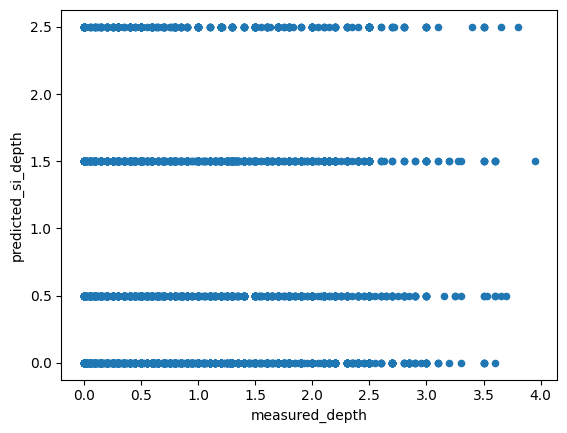

In [11]:
df.plot(x="measured_depth", y="predicted_si_depth", kind="scatter")

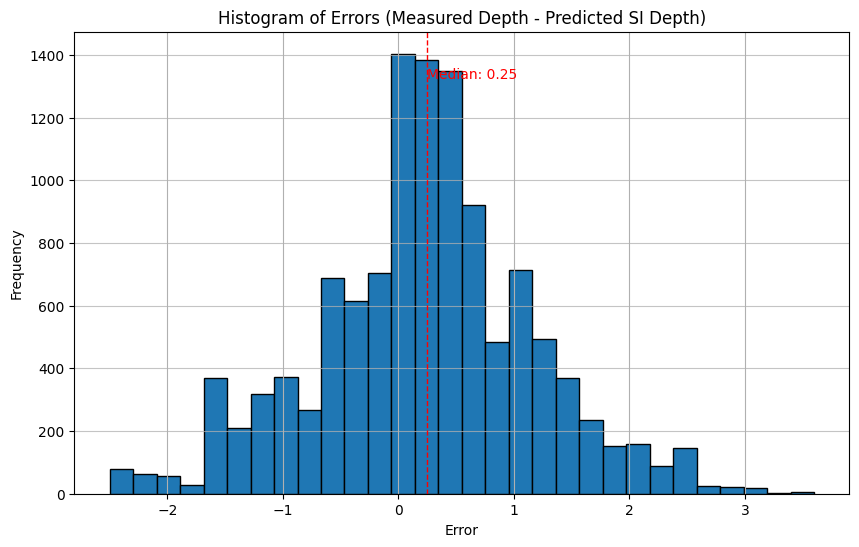

In [12]:
plot_errors_histogram(df, "measured_depth", "predicted_si_depth", title="Measured Depth - Predicted SI Depth")

<Axes: xlabel='measured_depth', ylabel='predicted_wri_depth'>

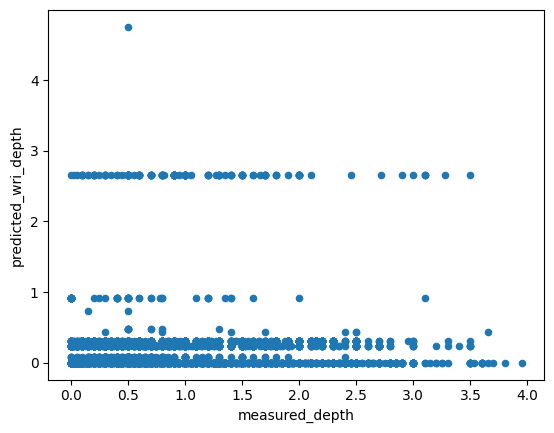

In [14]:
df.plot(x="measured_depth", y="predicted_wri_depth", kind="scatter")

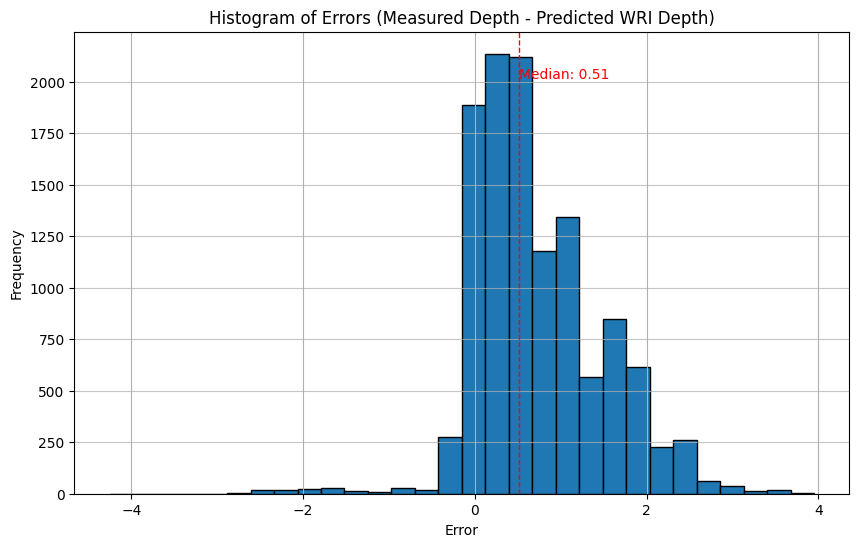

In [14]:
plot_errors_histogram(df, "measured_depth", "predicted_wri_depth", title="Measured Depth - Predicted WRI Depth")

In [19]:
df["predicted_wri_depth"]

0        0.000000
1        0.000000
2        0.000000
3        0.000000
4        0.482443
           ...   
13525    0.000000
13526    0.000000
13527    0.000000
13528    0.000000
13530    0.000000
Name: predicted_wri_depth, Length: 11740, dtype: float64

In [17]:
predictions = df["predicted_wri_depth"] - 0.51
predictions

0       -0.510000
1       -0.510000
2       -0.510000
3       -0.510000
4       -0.027557
           ...   
13525   -0.510000
13526   -0.510000
13527   -0.510000
13528   -0.510000
13530   -0.510000
Name: predicted_wri_depth, Length: 11740, dtype: float64

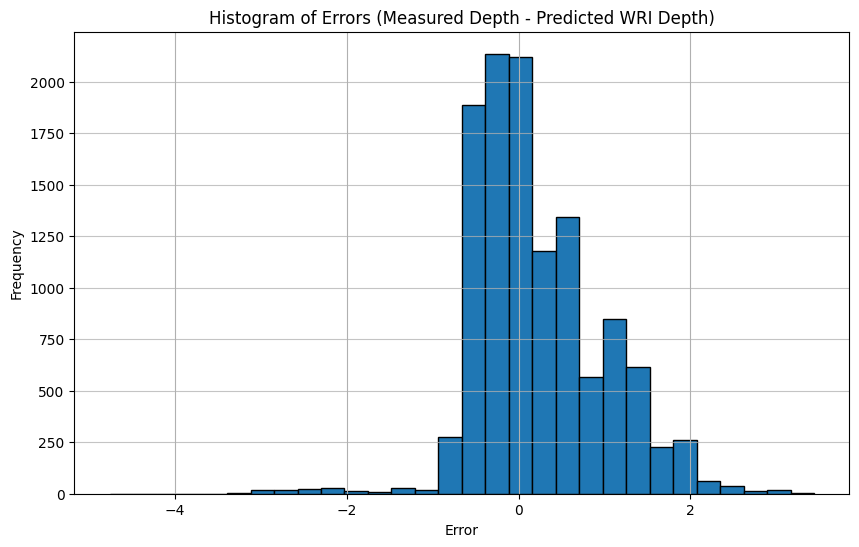

In [21]:
predictions = df["predicted_wri_depth"] + 0.51
errors = df["measured_depth"] - predictions
errors.hist(bins=30, edgecolor="black", figsize=(10, 6))
plt.title("Histogram of Errors (Measured Depth - Predicted WRI Depth)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()


# Categorize measured_depth into 4 categories


In [38]:
df["depth_category"] = pd.cut(df["measured_depth"], bins=[0, 0.5, 1.5, 2.5], labels=[0.5, 1.5, 2.5])
# df.shape
# df.head()
# df.groupby("depth_category").mean()
# df.groupby("depth_category").mean()

In [42]:
df["depth_category"].value_counts().sort_index()


depth_category
0.5    4277
1.5    4334
2.5    1757
Name: count, dtype: int64

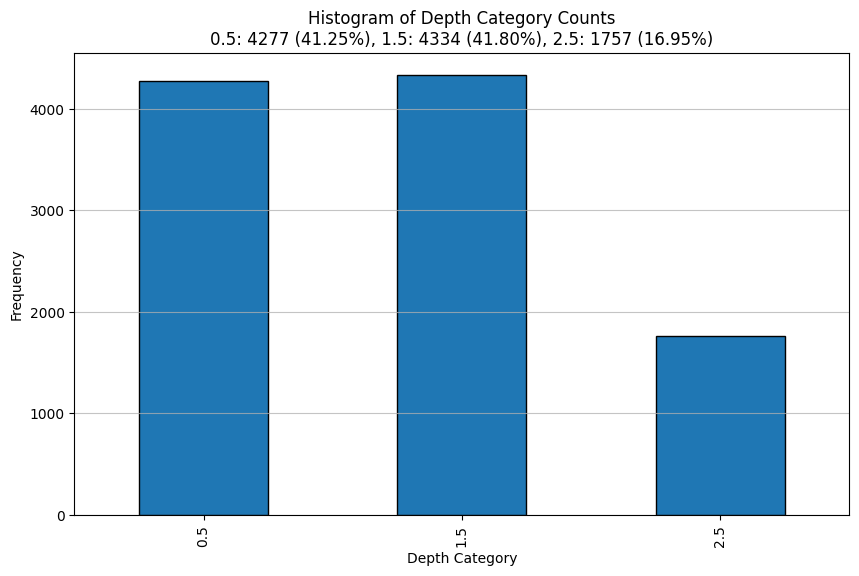

0.5: 4277 (41.25%), 1.5: 4334 (41.80%), 2.5: 1757 (16.95%)


In [58]:
value_counts = df["depth_category"].value_counts().sort_index()
value_counts.plot(kind="bar", edgecolor="black", figsize=(10, 6))

# Calculate relative percentages
total_count = value_counts.sum()
percentages = (value_counts / total_count) * 100

# Add text with percentages below the title
percent_text = ", ".join([f"{cat}: {count} ({percent:.2f}%)" for cat, count, percent in zip(value_counts.index, value_counts, percentages)])
plt.title(f"Histogram of Depth Category Counts\n{percent_text}")
# plt.title("Histogram of Depth Category Counts")
plt.xlabel("Depth Category")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()
print(percent_text)

<Axes: xlabel='depth_category', ylabel='predicted_si_depth'>

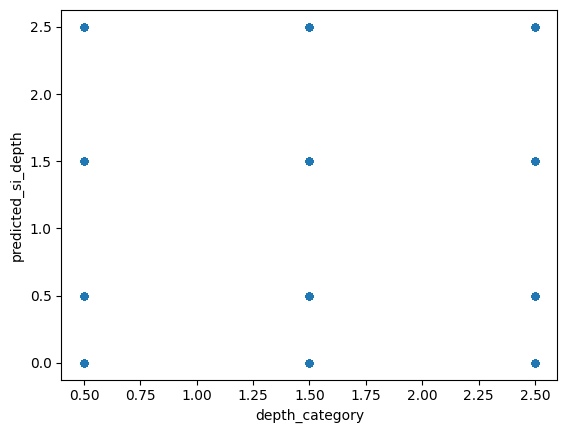

In [51]:
df.plot(x="depth_category", y="predicted_si_depth", kind="scatter")

In [52]:
def plot_confusion_matrix(df, true_column, predicted_column, title: str = "Confusion Matrix"):
    # First, let's bin the measured_depth into categories and do the same for predictions
    # Create categorical bins for the depths
    def categorize_depth(depth):
        if depth <= 0.5:
            return "0.5"
        elif depth <= 1.5:
            return "1.5"
        return "2.5"
    
    _df = df.copy()
    
    _df["depth_category_true"] = _df[true_column].apply(categorize_depth)
    _df["depth_category_pred"] = _df[predicted_column].apply(categorize_depth)

    # Calculate confusion matrix
    cm = confusion_matrix(_df["depth_category_true"], _df["depth_category_pred"])
    categories = ["0.5", "1.5", "2.5"]

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=categories, 
                yticklabels=categories)
    plt.title(title)
    plt.xlabel("Predicted Category")
    plt.ylabel("True Category")
    plt.show()

    # ---
    # Calculate metrics
    # ---
    accuracy = accuracy_score(_df["depth_category_true"], _df["depth_category_pred"])
    precision, recall, f1, support = precision_recall_fscore_support(
        _df["depth_category_true"], 
        _df["depth_category_pred"],
        labels=["0.5", "1.5", "2.5"],
        average=None
    )

    metrics_df = pd.DataFrame({
        "Category": ["0.5", "1.5", "2.5"],
        "Precision": precision,
        "Recall": recall,
        "Support": support
    })

    # Print overall accuracy
    print(f"Overall Classification Accuracy: {accuracy:.3f}\n")

    # Print per-category metrics
    print("Per-category metrics:")
    print(metrics_df.to_string(index=False))

    """
    Metrics explanation:
    - Accuracy: Proportion of correct predictions among total predictions
    - Precision: Proportion of correct positive predictions among all positive predictions for each category
    - Recall: Proportion of correct positive predictions among all actual positives for each category
    - Support: Number of samples in each category
    """
    

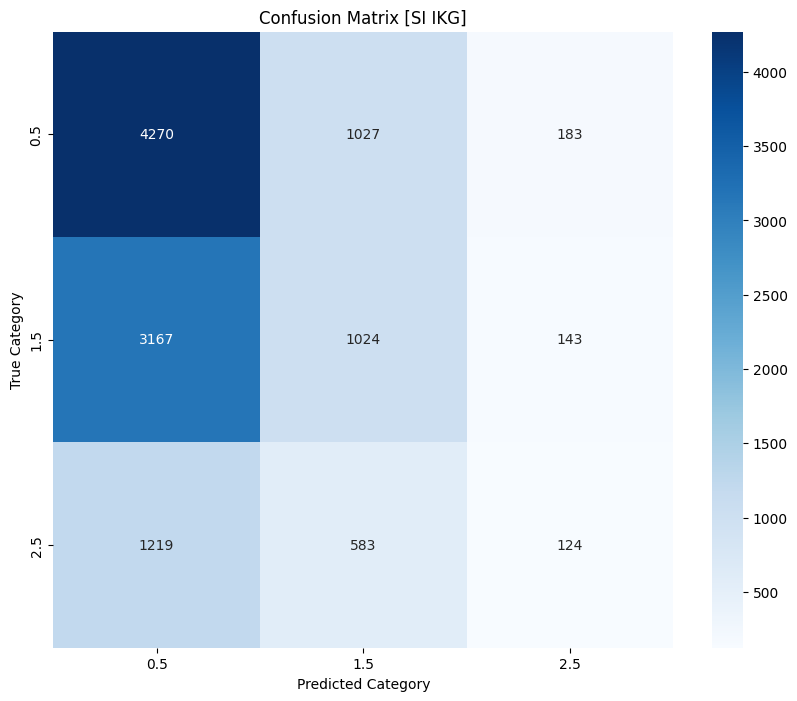

Overall Classification Accuracy: 0.461

Per-category metrics:
Category  Precision   Recall  Support
     0.5   0.493299 0.779197     5480
     1.5   0.388762 0.236271     4334
     2.5   0.275556 0.064382     1926


In [53]:
plot_confusion_matrix(df, "measured_depth", "predicted_si_depth", title="Confusion Matrix [SI IKG]")

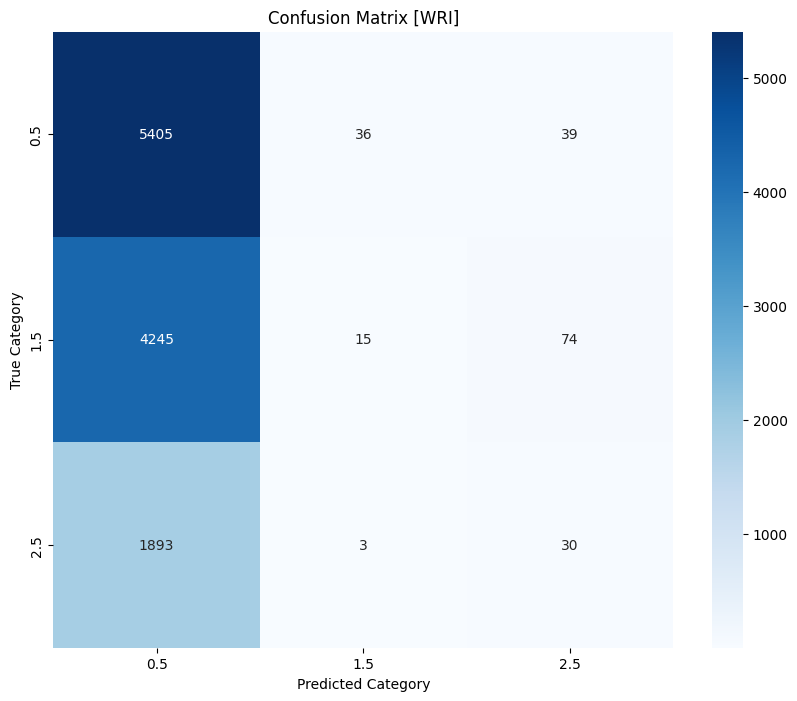

Overall Classification Accuracy: 0.464

Per-category metrics:
Category  Precision   Recall  Support
     0.5   0.468249 0.986314     5480
     1.5   0.277778 0.003461     4334
     2.5   0.209790 0.015576     1926


In [54]:
plot_confusion_matrix(df, "measured_depth", "predicted_wri_depth", title="Confusion Matrix [WRI]")